In [1]:
import os
import cv2
import numpy as np
import shutil
from tqdm import tqdm

ORIGINAL_DIR = '/kaggle/input/datasets/soumikrakshit/anime-faces'
FILTERED_DIR = '/kaggle/working/anime_faces_hair_filter'

if os.path.exists(FILTERED_DIR):
    shutil.rmtree(FILTERED_DIR)
os.makedirs(os.path.join(FILTERED_DIR, 'selected_hair'))

print("Iniciando a filtragem RIGOROSA por cor de cabelo (Loiro/Amarelo)...")
copied_count = 0

all_files = []
for root_dir, _, filenames in os.walk(ORIGINAL_DIR):
    for filename in filenames:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_files.append((root_dir, filename))

# --- AJUSTE: Intervalo mais fechado para Amarelo Puro ---
lower_yellow = np.array([20, 60, 60])
upper_yellow = np.array([32, 255, 255])

for root_dir, filename in tqdm(all_files):
    img_path = os.path.join(root_dir, filename)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
        
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    yellow_pixel_count = np.sum(mask == 255)
    
    # --- AJUSTE: Exigir mais pixels (mínimo de 850 pixels amarelos) ---
    if yellow_pixel_count > 850:
        dest_path_normal = os.path.join(FILTERED_DIR, 'selected_hair', f"norm_{filename}")
        cv2.imwrite(dest_path_normal, img)
        copied_count += 1
        
        img_flipped = cv2.flip(img, 1)
        dest_path_flip = os.path.join(FILTERED_DIR, 'selected_hair', f"flip_{filename}")
        cv2.imwrite(dest_path_flip, img_flipped)
        copied_count += 1

print(f"\nFiltragem concluída! Reunimos {copied_count} imagens estritamente loiras em '{FILTERED_DIR}/selected_hair'.")

Iniciando a filtragem RIGOROSA por cor de cabelo (Loiro/Amarelo)...


100%|██████████| 43102/43102 [05:33<00:00, 129.17it/s]


Filtragem concluída! Reunimos 2196 imagens estritamente loiras em '/kaggle/working/anime_faces_hair_filter/selected_hair'.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import numpy as np 
import pandas as pd 
import os

# Em vez de printar todas as milhares de imagens, vamos listar apenas as pastas principais
print("--- Pastas disponíveis no Input ---")
for dirname, dirnames, _ in os.walk('/kaggle/input'):
    for subdirname in dirnames:
        print(os.path.join(dirname, subdirname))

print("\n--- Espaço de Output verificado ---")
print("Seus resultados salvos irão para: /kaggle/working/")
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

--- Pastas disponíveis no Input ---
/kaggle/input/datasets
/kaggle/input/datasets/soumikrakshit
/kaggle/input/datasets/soumikrakshit/anime-faces
/kaggle/input/datasets/soumikrakshit/anime-faces/data
/kaggle/input/datasets/soumikrakshit/anime-faces/data/data

--- Espaço de Output verificado ---
Seus resultados salvos irão para: /kaggle/working/


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import os

# --- Configurações Fixas para o Anime Faces ---
latent_dim = 100
target_channels = 3  # RGB
image_size = 64      # Resolução nativa do dataset
batch_size = 128     # Aumentei para 128 (comum para esse dataset rodar bem na GPU do Kaggle)
epochs = 200          
learning_rate = 0.0002

# Garante o uso da GPU do Kaggle (mude a aceleração do notebook para P100 ou T4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformação ideal para DCGAN
transform = transforms.Compose([
    # O dataset já é 64x64, mas o Resize garante caso haja alguma exceção
    transforms.Resize((image_size, image_size)), 
    transforms.ToTensor(),
    # Normaliza os 3 canais para o intervalo [-1, 1], que casa com a saída Tanh do Gerador
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) 
])

# --- CORREÇÃO DO CAMINHO (Aspas corrigidas no final) ---
DATASET_PATH = '/kaggle/working/anime_faces_hair_filter'

if os.path.exists(DATASET_PATH):
    try:
        dataset = torchvision.datasets.ImageFolder(root=DATASET_PATH, transform=transform)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
        print(f"Sucesso! {len(dataset)} imagens de anime carregadas.")
    except Exception as e:
        print(f"Erro ao carregar com ImageFolder: {e}")
else:
    print(f"Diretório não encontrado em {DATASET_PATH}. Verifique o caminho no painel 'Input' do Kaggle.")

Sucesso! 1098 imagens de anime carregadas.


Célula 3: O Gerador (Generator)O gerador pega o vetor latente de dimensão 100 e vai "expandindo" o mapa de recursos através de convoluções transpostas (ConvTranspose2d) até chegar no formato $3 \times 64 \times 64$.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, channels):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Entrada: Vetor latente Z remodelado para (batch, 100, 1, 1)
            nn.Unflatten(1, (latent_dim, 1, 1)),
            
            # Estado inicial: expande Z para 512 filtros e tamanho 4x4
            nn.ConvTranspose2d(latent_dim, 512, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            # Mapeia de 4x4 -> para 8x8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # Mapeia de 8x8 -> para 16x16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # Mapeia de 16x16 -> para 32x32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # Camada final: Mapeia de 32x32 -> para a imagem final de 64x64 com 3 canais (RGB)
            nn.ConvTranspose2d(64, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh() # Tanh normaliza a saída entre [-1, 1] para bater com nosso transform
        )

    def forward(self, z):
        return self.model(z)

Célula 4: O Discriminador (Discriminator)O discriminador faz o papel inverso: ele recebe uma imagem $3 \times 64 \times 64$ (real ou gerada) e vai reduzindo as dimensões através de convoluções com saltos (stride=2) até dar uma probabilidade final entre 0 e 1 (Falso ou Real) usando a função Sigmoid.

In [5]:
class Discriminator(nn.Module):
    def __init__(self, channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Entrada: Imagem de tamanho 3 x 64 x 64
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Reduz para 32x32
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Reduz para 16x16
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Reduz para 8x8
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Camada de classificação final (saída 1x1 que achatamos para um valor escalar único)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Flatten(),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

Célula 5: Inicialização das Redes, Otimizadores e Perda
Aqui nós instanciamos as redes na GPU, aplicamos a inicialização de pesos gaussiana recomendada pelo criador das DCGANs e configuramos o Adam usando os mesmos parâmetros de betas=(0.5, 0.999) e taxa de aprendizado que o seu professor sugeriu para conter as oscilações ruins.

In [6]:
# Função para inicializar os pesos das camadas convolucionais de forma estável
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Instanciando as redes com as variáveis globais da Célula 2
generator = Generator(latent_dim, target_channels).to(device)
discriminator = Discriminator(target_channels).to(device)

# Aplicando a inicialização de pesos
generator.apply(weights_init)
discriminator.apply(weights_init)

# Configurando a perda Binária e os otimizadores Adam equilibrados
criterion = nn.BCELoss().to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

print("Modelos e otimizadores inicializados com sucesso!")
print(generator)

Modelos e otimizadores inicializados com sucesso!
Generator(
  (model): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(100, 1, 1))
    (1): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): C

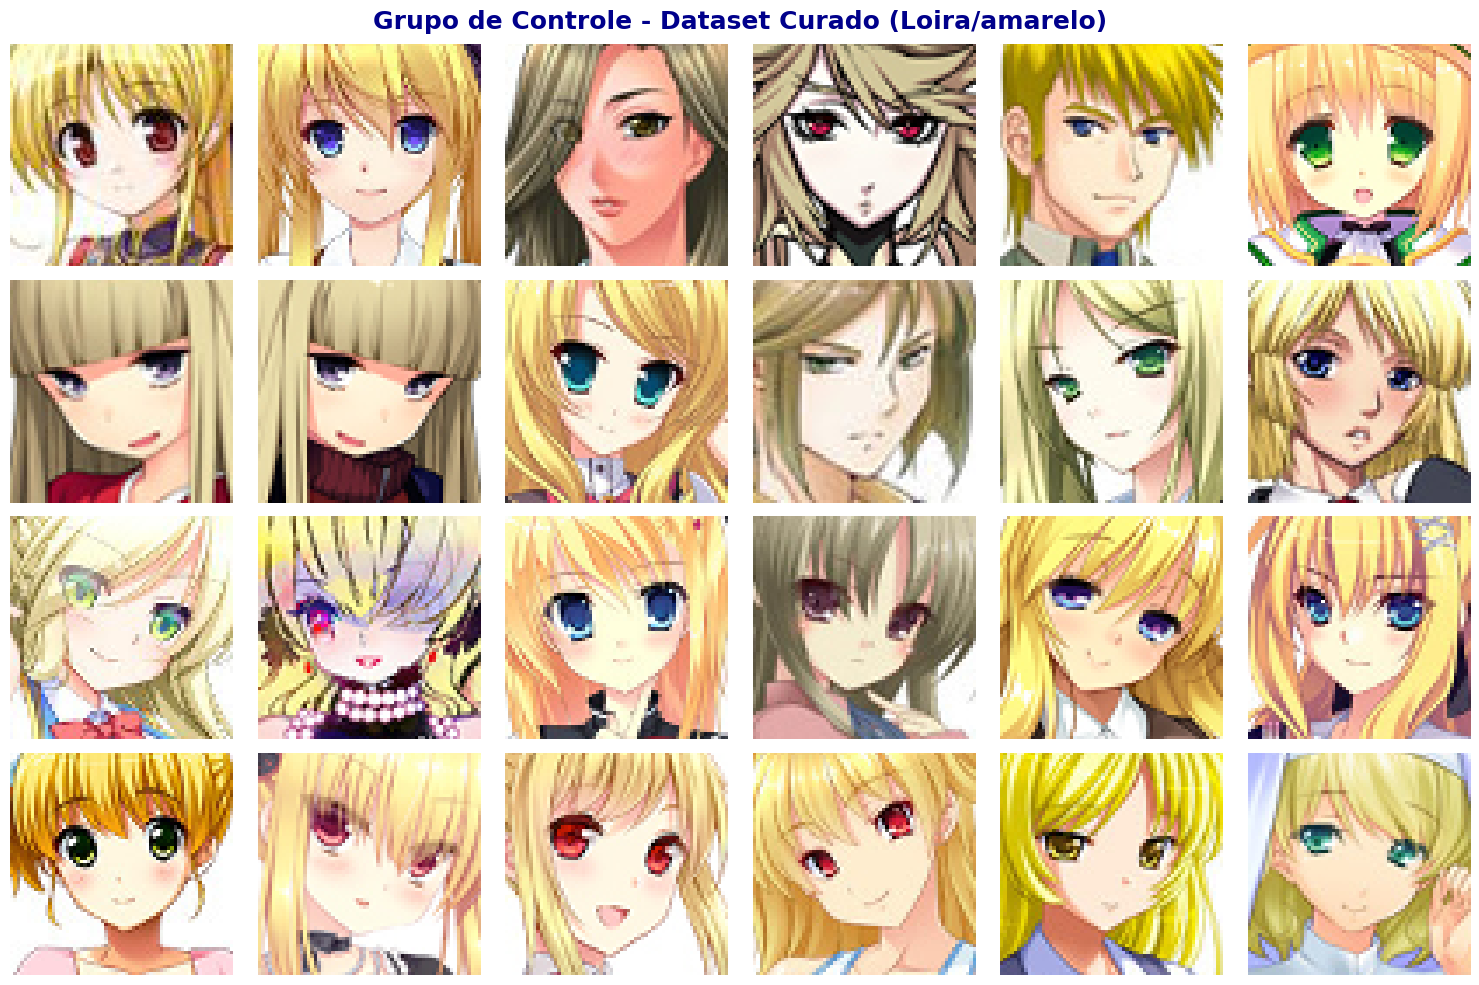

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pegar um único batch de imagens do novo dataloader (já filtrado e espelhado)
data_iter = iter(dataloader)
images, _ = next(data_iter)

# 2. Selecionar as primeiras 24 imagens para exibição
images_to_show = images[:24]

# 3. Configurar a janela de exibição do Matplotlib (4 linhas e 6 colunas = 24 imagens)
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
# Alterado o título para refletir a curadoria dos dados
fig.suptitle("Grupo de Controle - Dataset Curado (Loira/amarelo)", fontsize=18, fontweight='bold', color='darkblue')

for idx, ax in enumerate(axes.flat):
    # Pega a imagem do tensor (Canais, Altura, Largura)
    img = images_to_show[idx].cpu().numpy()
    
    # Transpõe de (C, H, W) para (H, W, C) para o formato do Matplotlib
    img = np.transpose(img, (1, 2, 0))
    
    # Desfaz a normalização: de [-1, 1] de volta para [0, 1]
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    
    # Plota a imagem no grid
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

Célula 6: A Função de Treinamento (train_anime_dcgan)
Esta função implementa o jogo adversarial clássico: o Discriminador tenta ficar bom em diferenciar o real do falso, enquanto o Gerador usa o feedback do Discriminador para criar rostos cada vez mais convincentes. Adicionamos a suavização de rótulos (real_labels = 0.9) para evitar que o Discriminador destrua o aprendizado do Gerador logo no início.

In [8]:
def train_anime_dcgan(generator, discriminator, dataloader, criterion, optimizer_G, optimizer_D, epochs):
    output_dir = '/kaggle/working/images_anime'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    print("Iniciando o treinamento adversarial na GPU...")
    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(dataloader):
            curr_batch_size = imgs.size(0)
            
            # --- Label Smoothing para estabilizar o treino ---
            real_labels = torch.full((curr_batch_size, 1), 0.9, device=device)
            fake_labels = torch.zeros(curr_batch_size, 1, device=device)

            # ================================================================ #
            # 1. Treinar o Discriminador                                       #
            # ================================================================ #
            optimizer_D.zero_grad()
            
            # Passar imagens reais do dataset
            real_imgs = imgs.to(device)
            output_real = discriminator(real_imgs)
            loss_real = criterion(output_real, real_labels)
            
            # --- CORREÇÃO DO RUNTIME ERROR ---
            # Geramos o vetor Z de forma plana (batch_size, 100)
            # Assim, a camada Unflatten do Gerador vai funcionar perfeitamente!
            z = torch.randn(curr_batch_size, latent_dim, device=device)
            fake_imgs = generator(z)
            
            # Isolar o gerador (.detach()) para calcular o erro apenas do discriminador
            output_fake = discriminator(fake_imgs.detach())
            loss_fake = criterion(output_fake, fake_labels)
            
            # Perda total e atualização do Discriminador
            d_loss = loss_real + loss_fake
            d_loss.backward()
            optimizer_D.step()

            # ================================================================ #
            # 2. Treinar o Gerador                                             #
            # ================================================================ #
            optimizer_G.zero_grad()
            
            # O gerador tenta fazer o discriminador classificar as falsas como reais (0.9)
            output_g = discriminator(fake_imgs)
            g_loss = criterion(output_g, real_labels) 
            
            # Atualização do Gerador
            g_loss.backward()
            optimizer_G.step()

            # Printar o progresso a cada 100 batches
            if i % 100 == 0:
                print(f"Época [{epoch}/{epochs}] Batch {i}/{len(dataloader)} | Perda D: {d_loss.item():.4f} | Perda G: {g_loss.item():.4f}")

        # Salvar uma grade de amostras de imagens geradas ao final de cada época
        save_image(fake_imgs[:25], f"{output_dir}/anime_epoch_{epoch}.png", nrow=5, normalize=True)
        print(f"--> Amostra da época {epoch} salva com sucesso em '{output_dir}/anime_epoch_{epoch}.png'\n")

Célula 7: Chamada de Execução

In [9]:
# Disparar o treinamento da DCGAN para os rostos de anime
train_anime_dcgan(generator, discriminator, dataloader, criterion, optimizer_G, optimizer_D, epochs)

Iniciando o treinamento adversarial na GPU...
Época [0/200] Batch 0/8 | Perda D: 1.7180 | Perda G: 4.7658
--> Amostra da época 0 salva com sucesso em '/kaggle/working/images_anime/anime_epoch_0.png'

Época [1/200] Batch 0/8 | Perda D: 0.4677 | Perda G: 6.9081
--> Amostra da época 1 salva com sucesso em '/kaggle/working/images_anime/anime_epoch_1.png'

Época [2/200] Batch 0/8 | Perda D: 0.4597 | Perda G: 8.3965
--> Amostra da época 2 salva com sucesso em '/kaggle/working/images_anime/anime_epoch_2.png'

Época [3/200] Batch 0/8 | Perda D: 0.4215 | Perda G: 13.9471
--> Amostra da época 3 salva com sucesso em '/kaggle/working/images_anime/anime_epoch_3.png'

Época [4/200] Batch 0/8 | Perda D: 0.7154 | Perda G: 4.3534
--> Amostra da época 4 salva com sucesso em '/kaggle/working/images_anime/anime_epoch_4.png'

Época [5/200] Batch 0/8 | Perda D: 0.4346 | Perda G: 33.4941
--> Amostra da época 5 salva com sucesso em '/kaggle/working/images_anime/anime_epoch_5.png'

Época [6/200] Batch 0/8 | Pe

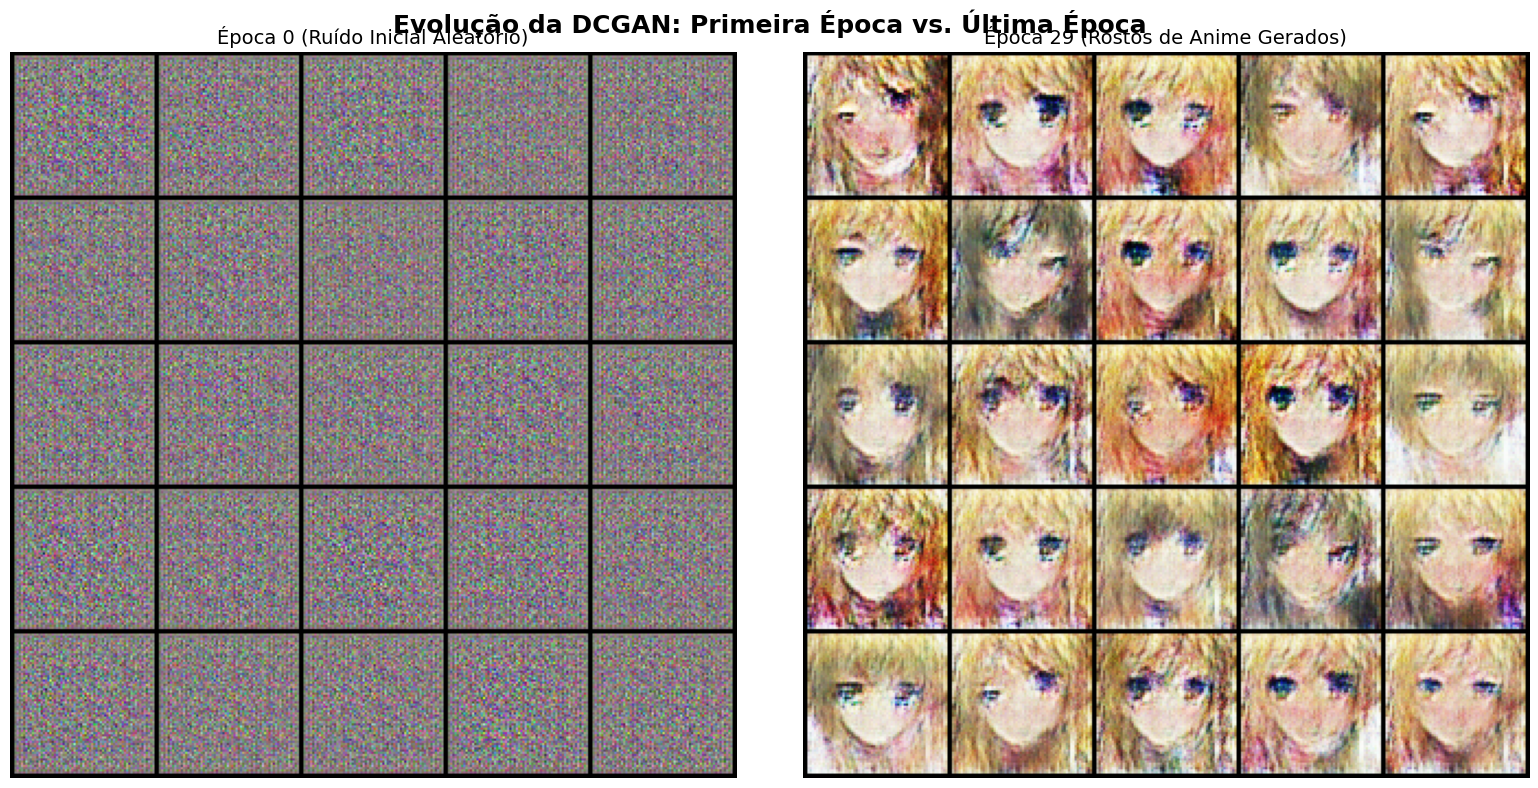

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Caminho onde as imagens foram salvas
output_dir = '/kaggle/working/images_anime'

# Definindo os caminhos da primeira (Época 0) e da última (Época 29)
img_first_path = f"{output_dir}/anime_epoch_0.png"
img_last_path = f"{output_dir}/anime_epoch_199.png" # 29 é a última das 30 épocas (0 a 29)

# Configurando a janela de exibição lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Evolução da DCGAN: Primeira Época vs. Última Época", fontsize=18, fontweight='bold')

# 1. Plotar a Primeira Época
if os.path.exists(img_first_path):
    img_first = Image.open(img_first_path)
    axes[0].imshow(img_first)
    axes[0].set_title("Época 0 (Ruído Inicial Aleatório)", fontsize=14)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, "Imagem da Época 0 não encontrada.", ha='center', va='center')
    axes[0].axis('off')

# 2. Plotar a Última Época
if os.path.exists(img_last_path):
    img_last = Image.open(img_last_path)
    axes[1].imshow(img_last)
    axes[1].set_title("Época 29 (Rostos de Anime Gerados)", fontsize=14)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, "Aguarde o treino acabar para ver a Época 29.", ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()